<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Introdução ao PyTorch para Redes Neurais Convolucionais

**Autor:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

---
## Bloco 1 — Tensores e Operações Básicas

Tensores são a estrutura de dados fundamental do PyTorch. Funcionam como arrays do NumPy, mas rodam em GPU e suportam diferenciação automática.

### Criando tensores

Existem várias formas de criar tensores: a partir de listas Python, com valores aleatórios, ou preenchidos com zeros e uns.

In [1]:
import torch

# A partir de uma lista
t1 = torch.tensor([1, 2, 3, 4])
print(t1)

tensor([1, 2, 3, 4])


In [2]:
# Tensores preenchidos
zeros = torch.zeros(3, 4)
uns = torch.ones(3, 4)
aleatorio = torch.rand(3, 4)

print("Zeros:")
print(zeros)
print()
print("Uns:")
print(uns)
print()
print("Aleatório:")
print(aleatorio)

Zeros:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Uns:
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

Aleatório:
tensor([[0.2096, 0.5861, 0.7770, 0.5790],
        [0.4727, 0.5605, 0.5942, 0.9718],
        [0.8687, 0.6099, 0.9699, 0.0796]])


### Shape, dtype e reshape

Todo tensor tem um shape (suas dimensões) e um dtype (tipo dos dados). Podemos mudar o formato com `reshape` ou `view`.

In [3]:
t = torch.rand(2, 3, 4)
print("Shape:", t.shape)
print("Dtype:", t.dtype)
print("Número de dimensões:", t.ndim)
print("Número total de elementos:", t.numel())

Shape: torch.Size([2, 3, 4])
Dtype: torch.float32
Número de dimensões: 3
Número total de elementos: 24


In [4]:
t = torch.arange(12)
print("Original:", t.shape)

t_reshaped = t.reshape(3, 4)
print("Reshape (3,4):")
print(t_reshaped)

t_reshaped2 = t.reshape(2, 2, 3)
print("Reshape (2,2,3):")
print(t_reshaped2)

Original: torch.Size([12])
Reshape (3,4):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Reshape (2,2,3):
tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]]])


### Indexação e slicing

A indexação funciona como no NumPy.

In [5]:
t = torch.arange(12).reshape(3, 4)
print("Tensor:")
print(t)
print()
print("Elemento [1, 2]:", t[1, 2])
print("Primeira linha:", t[0])
print("Segunda coluna:", t[:, 1])
print("Submatriz [0:2, 1:3]:")
print(t[0:2, 1:3])

Tensor:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

Elemento [1, 2]: tensor(6)
Primeira linha: tensor([0, 1, 2, 3])
Segunda coluna: tensor([1, 5, 9])
Submatriz [0:2, 1:3]:
tensor([[1, 2],
        [5, 6]])


### Operações matemáticas

PyTorch suporta operações elemento a elemento, multiplicação matricial e diversas funções matemáticas.

In [6]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Soma:", a + b)
print("Multiplicação:", a * b)
print("Potência:", a ** 2)
print("Produto escalar:", torch.dot(a, b))

Soma: tensor([5., 7., 9.])
Multiplicação: tensor([ 4., 10., 18.])
Potência: tensor([1., 4., 9.])
Produto escalar: tensor(32.)


In [7]:
# Multiplicação matricial
A = torch.rand(2, 3)
B = torch.rand(3, 4)

C = A @ B  # equivalente a torch.matmul(A, B)
print("A shape:", A.shape)
print("B shape:", B.shape)
print("C = A @ B shape:", C.shape)
print(C)

A shape: torch.Size([2, 3])
B shape: torch.Size([3, 4])
C = A @ B shape: torch.Size([2, 4])
tensor([[0.4845, 0.5920, 0.5575, 0.4166],
        [0.7671, 0.8397, 0.7561, 0.5782]])


### GPU

Se houver uma GPU disponível, podemos mover tensores para ela. Operações entre tensores precisam estar no mesmo device.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device disponível:", device)

t = torch.rand(3, 3)
t_gpu = t.to(device)
print("Tensor no device:", t_gpu.device)

Device disponível: cpu
Tensor no device: cpu


---
## Bloco 2 — Autograd

O autograd é o motor de diferenciação automática do PyTorch. Ele rastreia operações em tensores com `requires_grad=True` e calcula gradientes automaticamente com `backward()`.

### Gradientes básicos

In [9]:
x = torch.tensor(3.0, requires_grad=True)

y = x ** 2 + 2 * x + 1  # y = x^2 + 2x + 1

y.backward()  # dy/dx = 2x + 2

print("x =", x.item())
print("y =", y.item())
print("dy/dx =", x.grad.item())  # esperado: 2*3 + 2 = 8

x = 3.0
y = 16.0
dy/dx = 8.0


In [10]:
# Com vetores
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

y = (x ** 2).sum()

y.backward()

print("x:", x.data)
print("dy/dx:", x.grad)  # esperado: 2*x = [2, 4, 6]

x: tensor([1., 2., 3.])
dy/dx: tensor([2., 4., 6.])


### Regressão Linear na mão

Vamos usar o autograd para treinar uma regressão linear do zero, mostrando o que acontece dentro de um loop de treino.

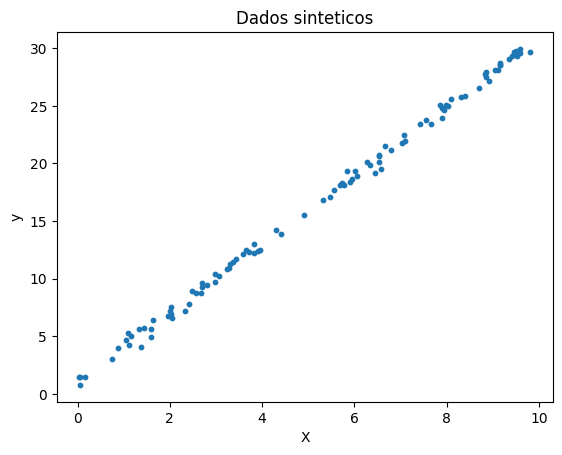

In [11]:
import matplotlib.pyplot as plt

# Dados sintéticos: y = 3x + 1 + ruido
torch.manual_seed(42)
X = torch.rand(100, 1) * 10
y_true = 3 * X + 1 + torch.randn(100, 1) * 0.5

plt.scatter(X.numpy(), y_true.numpy(), s=10)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dados sintéticos")
plt.show()

In [12]:
# Parâmetros treináveis
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

lr = 0.01
losses = []

for epoch in range(100):
    # Forward
    y_pred = w * X + b

    # Loss (MSE)
    loss = ((y_pred - y_true) ** 2).mean()

    # Backward
    loss.backward()

    # Atualização dos pesos (sem rastrear gradientes)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Zerar gradientes para a próxima iteração
    w.grad.zero_()
    b.grad.zero_()

    losses.append(loss.item())

print(f"w final: {w.item():.4f} (esperado: 3.0)")
print(f"b final: {b.item():.4f} (esperado: 1.0)")

w final: 3.0374 (esperado: 3.0)
b final: 0.7055 (esperado: 1.0)


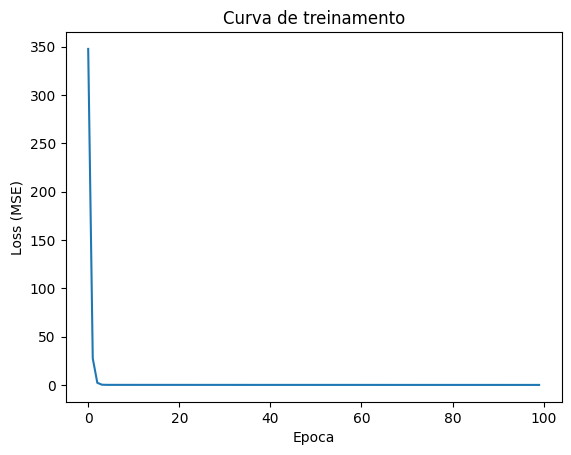

In [13]:
plt.plot(losses)
plt.xlabel("Época")
plt.ylabel("Loss (MSE)")
plt.title("Curva de treinamento")
plt.show()

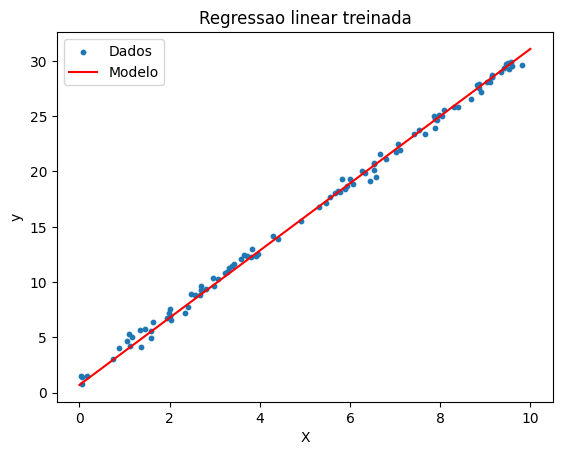

In [14]:
# Visualizar o ajuste
plt.scatter(X.numpy(), y_true.numpy(), s=10, label="Dados")
x_line = torch.linspace(0, 10, 100)
y_line = w.item() * x_line + b.item()
plt.plot(x_line.numpy(), y_line.numpy(), color="red", label="Modelo")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Regressão linear treinada")
plt.show()

---
## Bloco 3 — Datasets e DataLoader

O PyTorch oferece o `torchvision` com datasets prontos e o `DataLoader` para iterar sobre os dados em batches.

### Carregando o CIFAR-10

O CIFAR-10 tem 60.000 imagens coloridas 32x32 divididas em 10 classes.

In [15]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

print("Treino:", len(train_dataset), "imagens")
print("Teste:", len(test_dataset), "imagens")
print("Classes:", train_dataset.classes)

100%|██████████| 170M/170M [00:05<00:00, 29.0MB/s]


Treino: 50000 imagens
Teste: 10000 imagens
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### DataLoader

O DataLoader organiza os dados em batches e permite embaralhar.

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Número de batches no treino:", len(train_loader))
print("Número de batches no teste:", len(test_loader))

Número de batches no treino: 782
Número de batches no teste: 157


### Visualizando um batch

In [17]:
images, labels = next(iter(train_loader))
print("Shape do batch de imagens:", images.shape)
print("Shape dos labels:", labels.shape)

Shape do batch de imagens: torch.Size([64, 3, 32, 32])
Shape dos labels: torch.Size([64])


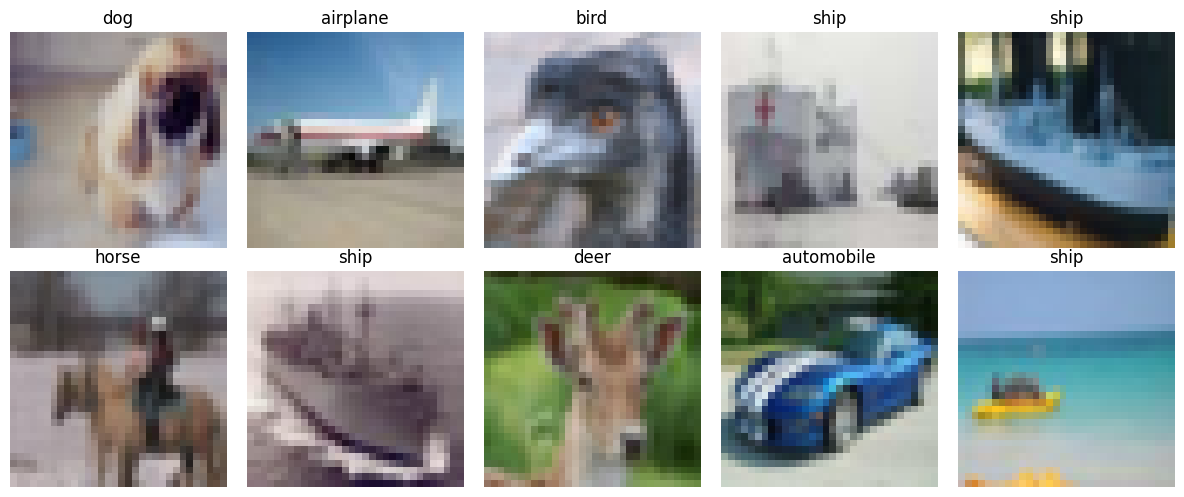

In [18]:
classes = train_dataset.classes

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = images[i]
    img = img * 0.5 + 0.5  # desnormalizar
    img = img.permute(1, 2, 0)  # CHW -> HWC
    ax.imshow(img.numpy())
    ax.set_title(classes[labels[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## Bloco 4 — Construindo uma CNN

Uma CNN extrai features espaciais da imagem através de filtros (convoluções) e reduz a resolução com pooling, antes de classificar com camadas fully connected.

### Versão mínima

A CNN mais simples possível: uma camada convolucional, um pooling e uma camada fully connected.

In [19]:
import torch.nn as nn

class CNNSimples(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 16 * 16, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model_simples = CNNSimples()
print(model_simples)

CNNSimples(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=10, bias=True)
)


### Verificando os shapes

Vamos acompanhar como o tensor muda de shape conforme passa pelas camadas.

In [20]:
x = images[:4]  # pegar 4 imagens do batch
print("Entrada:", x.shape)

x = model_simples.conv1(x)
print("Após Conv2d(3, 16, 3, padding=1):", x.shape)

x = model_simples.pool(torch.relu(x))
print("Após ReLU + MaxPool2d(2):", x.shape)

x = x.view(x.size(0), -1)
print("Após flatten:", x.shape)

x = model_simples.fc1(x)
print("Após Linear:", x.shape)

Entrada: torch.Size([4, 3, 32, 32])
Após Conv2d(3, 16, 3, padding=1): torch.Size([4, 16, 32, 32])
Após ReLU + MaxPool2d(2): torch.Size([4, 16, 16, 16])
Após flatten: torch.Size([4, 4096])
Após Linear: torch.Size([4, 10])


### Versão melhorada

CNN mais robusta com mais camadas convolucionais, BatchNorm e Dropout.

In [21]:
class CNNMelhorada(nn.Module):
    def __init__(self):
        super().__init__()
        # Bloco 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.25)

        # Bloco 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)

        # Classificador
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.drop3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Bloco 1
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))

        # Bloco 2
        x = torch.relu(self.bn3(self.conv3(x)))
        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))

        # Classificador
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.drop3(x)
        x = self.fc2(x)
        return x

model = CNNMelhorada()
print(model)

CNNMelhorada(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (d

In [22]:
# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total de parâmetros: {total_params:,}")
print(f"Parâmetros treináveis: {trainable_params:,}")

Total de parâmetros: 591,658
Parâmetros treináveis: 591,658


---
## Bloco 5 — Loop de Treino

Vamos treinar a CNN melhorada no CIFAR-10.

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Treinando em:", device)

model = CNNMelhorada().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Treinando em: cpu


In [24]:
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Época {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

Época 1/10 - Loss: 1.6498
Época 2/10 - Loss: 1.3698
Época 3/10 - Loss: 1.2456
Época 4/10 - Loss: 1.1759
Época 5/10 - Loss: 1.1233
Época 6/10 - Loss: 1.0854
Época 7/10 - Loss: 1.0506
Época 8/10 - Loss: 1.0261
Época 9/10 - Loss: 0.9991
Época 10/10 - Loss: 0.9746


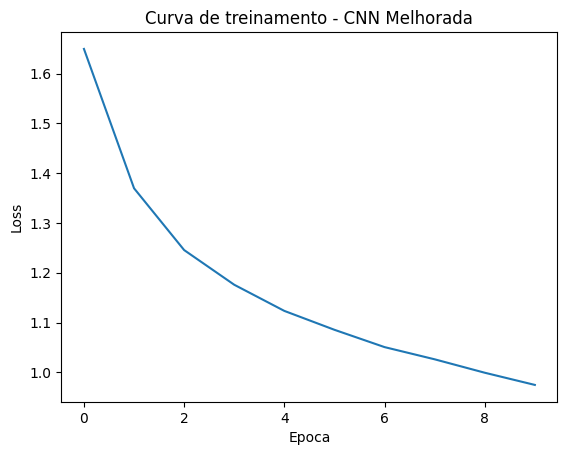

In [25]:
plt.plot(train_losses)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de treinamento - CNN Melhorada")
plt.show()

---
## Bloco 6 — Avaliação

Vamos avaliar o modelo no conjunto de teste.

In [26]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Acurácia no teste: {accuracy:.2f}%")

Acurácia no teste: 74.13%


### Visualizando predições

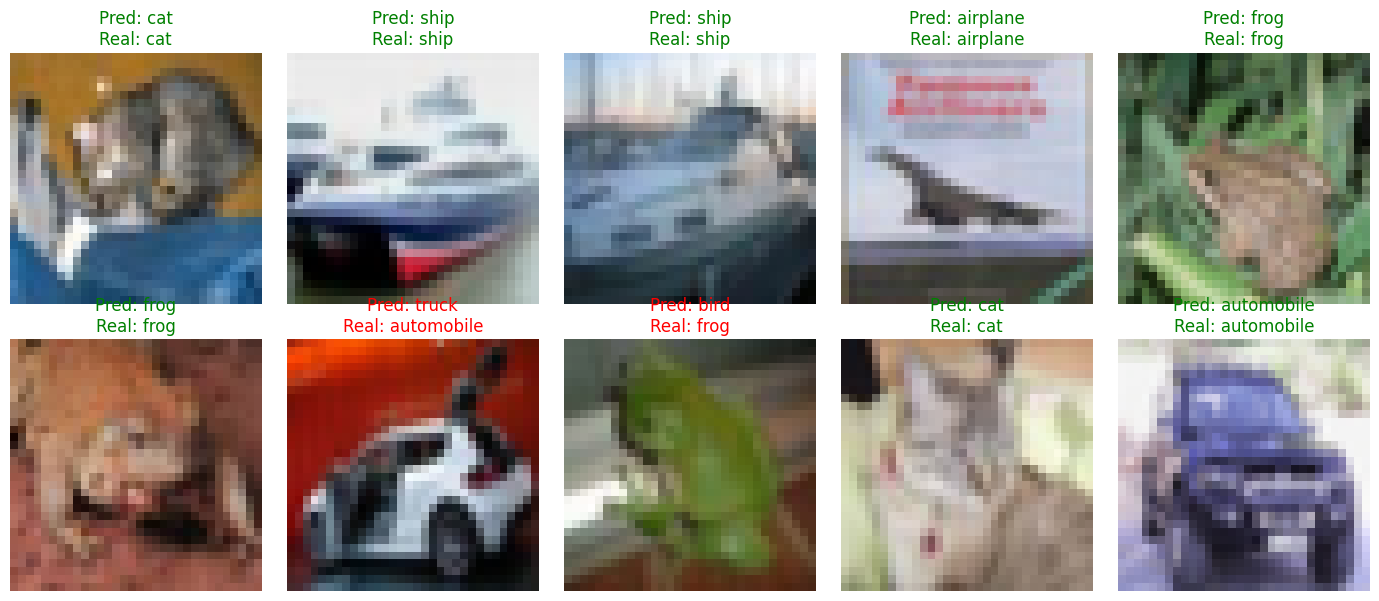

In [27]:
classes = test_dataset.classes

# Pegar um batch do teste
images, labels = next(iter(test_loader))
images_gpu = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images_gpu)
    _, preds = torch.max(outputs, 1)

preds = preds.cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = images[i] * 0.5 + 0.5
    img = img.permute(1, 2, 0)
    ax.imshow(img.numpy())

    color = "green" if preds[i] == labels[i] else "red"
    ax.set_title(f"Pred: {classes[preds[i]]}\nReal: {classes[labels[i]]}", color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Acurácia por classe

In [28]:
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for i in range(labels.size(0)):
            label = labels[i].item()
            class_total[label] += 1
            if predicted[i] == labels[i]:
                class_correct[label] += 1

classes = test_dataset.classes
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:>10s}: {acc:.1f}%")

  airplane: 81.7%
automobile: 88.1%
      bird: 65.1%
       cat: 52.7%
      deer: 60.8%
       dog: 54.7%
      frog: 86.8%
     horse: 74.6%
      ship: 87.5%
     truck: 89.3%
